In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [4]:
pd.read_csv('data/train.csv').to_parquet('data/train.parquet', index=False)
pd.read_csv('data/test.csv').to_parquet('data/test.parquet', index=False)

In [2]:
os.listdir()

['data', 'eda.ipynb']

In [3]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
original = pd.read_parquet('data/original.parquet')

In [4]:
original.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
original.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [8]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [15]:
cat_cols = [i for i in train.columns if train[i].dtype == 'object']
for i in cat_cols:
    print('---------------')
    print('---------------')
    if i == 'Churn':
        continue
    print(train[[i, 'Churn']].value_counts())
    

---------------
---------------
gender  Churn
Female  No       230615
Male    No       229762
Female  Yes       68123
Male    Yes       65694
Name: count, dtype: int64
---------------
---------------
Partner  Churn
Yes      No       268137
No       No       192240
         Yes       92400
Yes      Yes       41417
Name: count, dtype: int64
---------------
---------------
Dependents  Churn
No          No       293636
Yes         No       166741
No          Yes      120726
Yes         Yes       13091
Name: count, dtype: int64
---------------
---------------
PhoneService  Churn
Yes           No       430180
              Yes      127713
No            No        30197
              Yes        6104
Name: count, dtype: int64
---------------
---------------
MultipleLines     Churn
No                No       231717
Yes               No       198463
                  Yes       76046
No                Yes       51667
No phone service  No        30197
                  Yes        6104
Name: count, 

In [16]:
train['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [20]:
df = train.copy()
df['target'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['Churn', 'id'])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,0
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,0
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,0
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,0


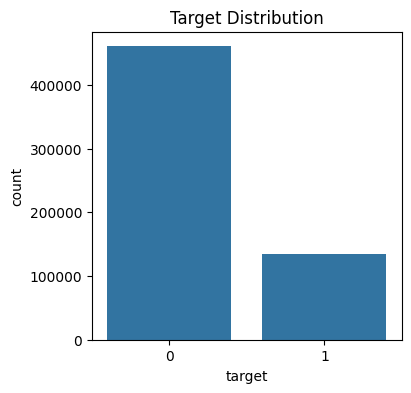

In [21]:
plt.figure(figsize=(4,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()


In [25]:
def plot_binned_target(df, feature, bins=50):
    temp = df[[feature, "target"]].copy()
    temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    
    grouped = temp.groupby("bin")["target"].mean()
    
    plt.figure(figsize=(8,4))
    grouped.plot(marker="o")
    plt.ylabel("P(Heart Disease = Presence)")
    plt.title(f"{feature} vs Heart Disease (Binned)")
    plt.xticks(rotation=45)
    plt.show()


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

C:\Users\16yas\AppData\Local\Temp\ipykernel_40292\1119433929.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby("bin")["target"].mean()


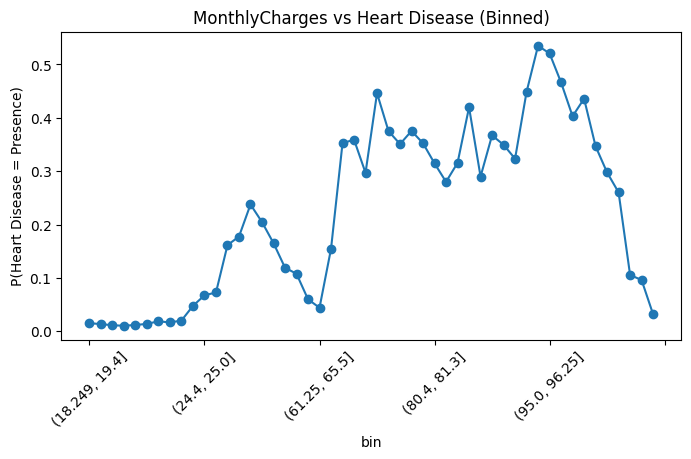

C:\Users\16yas\AppData\Local\Temp\ipykernel_40292\1119433929.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby("bin")["target"].mean()


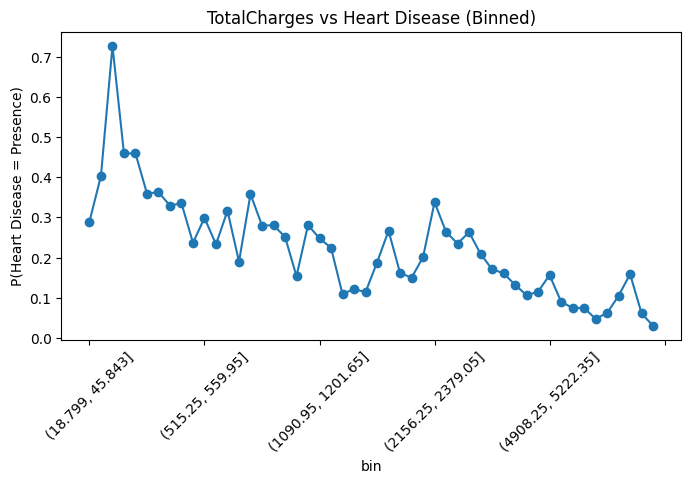

In [27]:
plot_binned_target(df, "MonthlyCharges")
plot_binned_target(df, "TotalCharges")


In [30]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

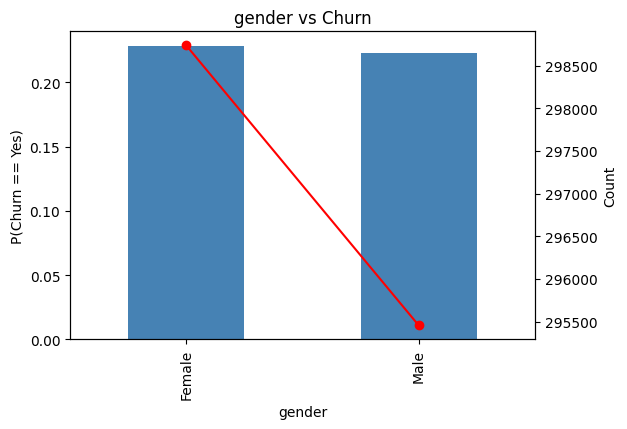

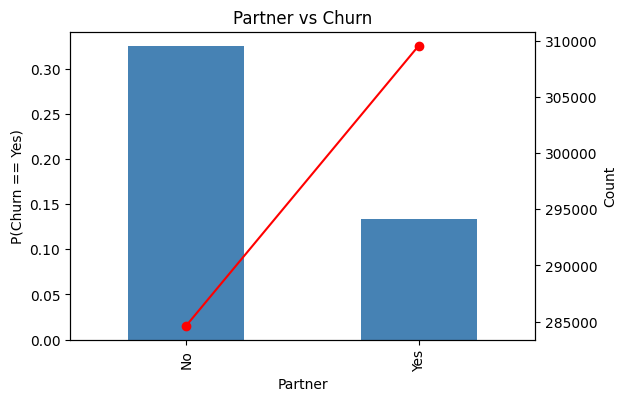

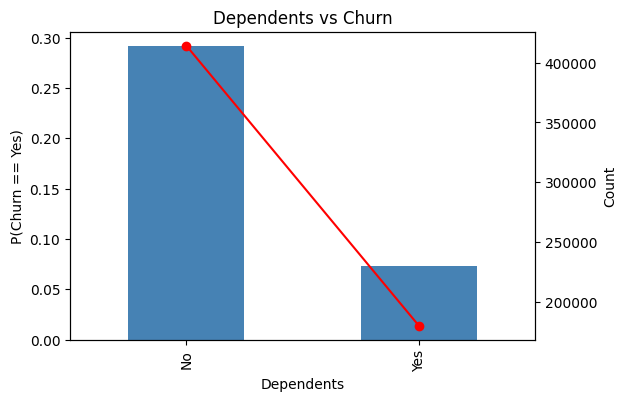

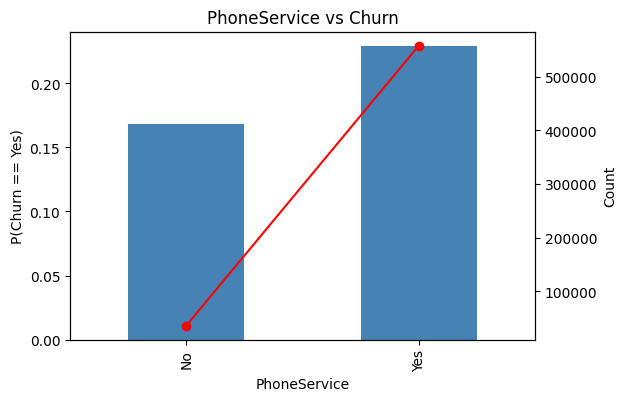

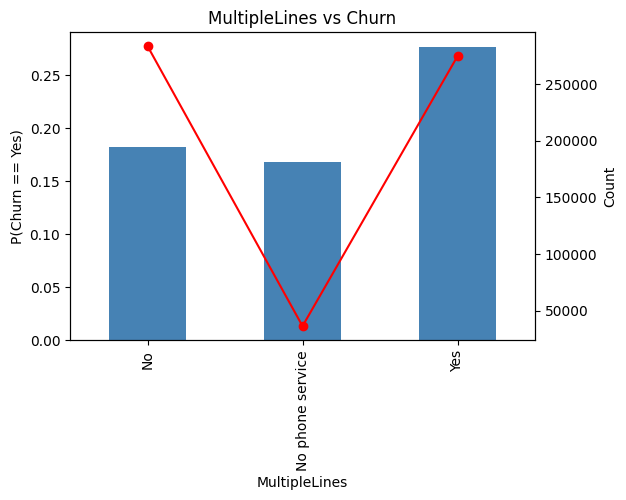

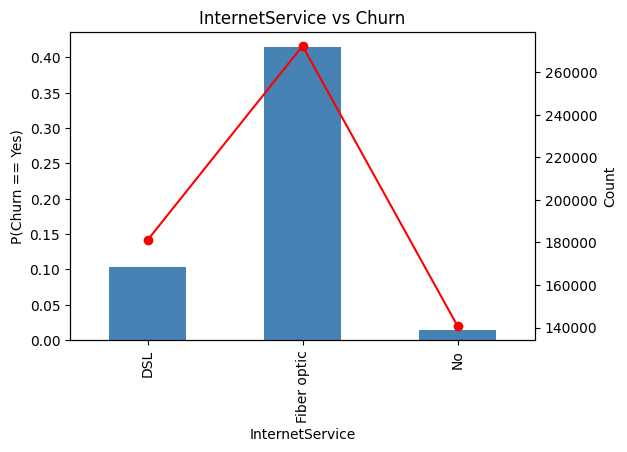

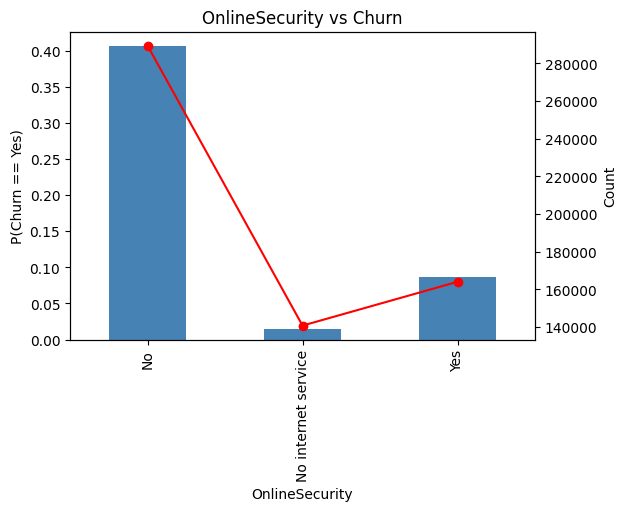

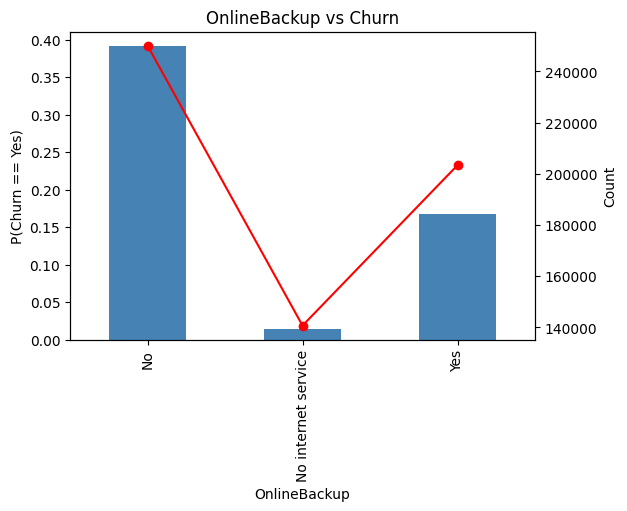

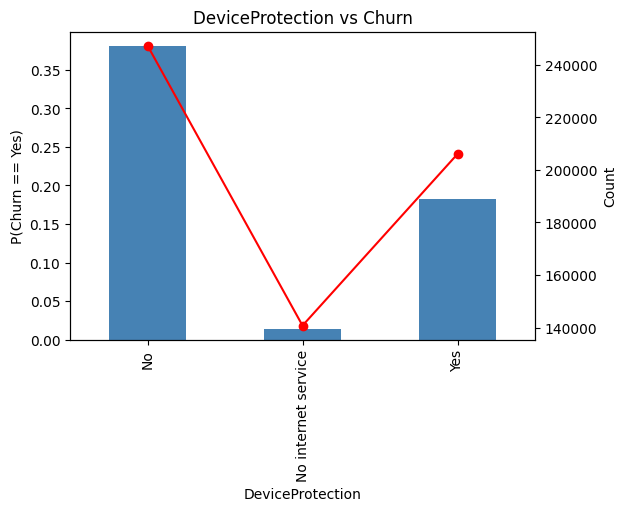

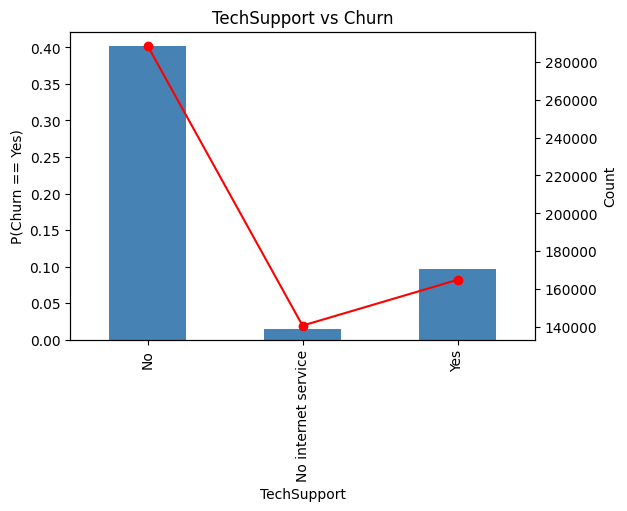

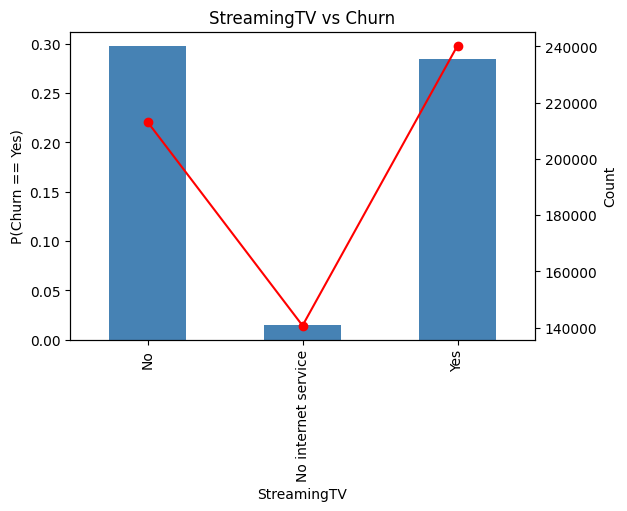

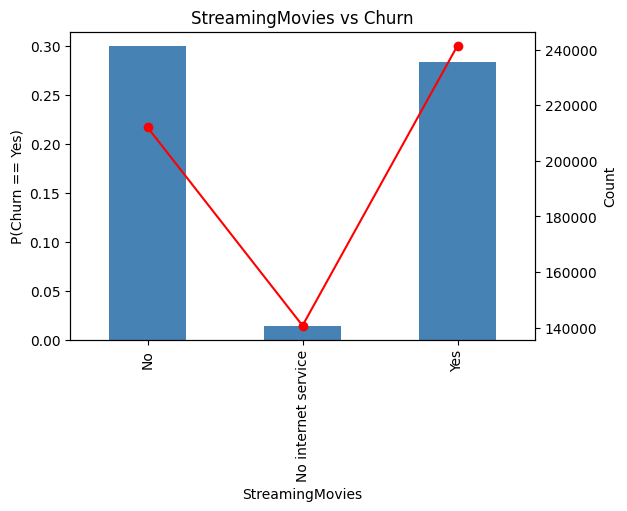

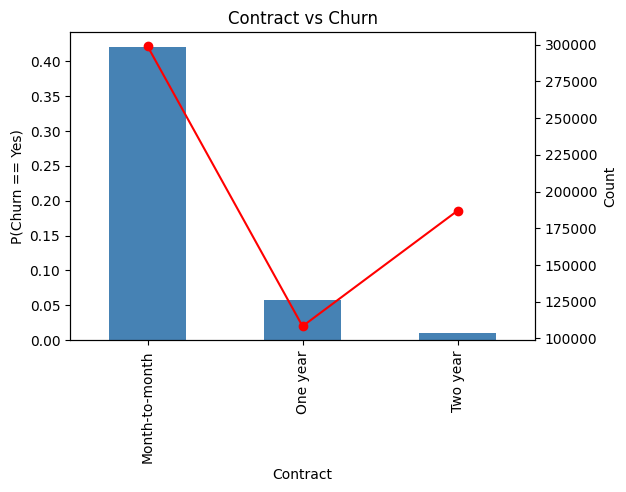

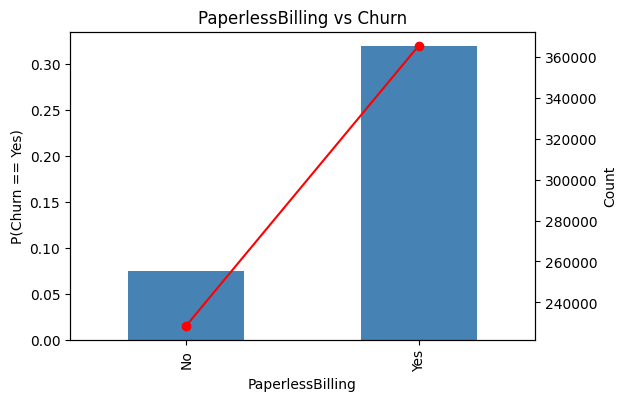

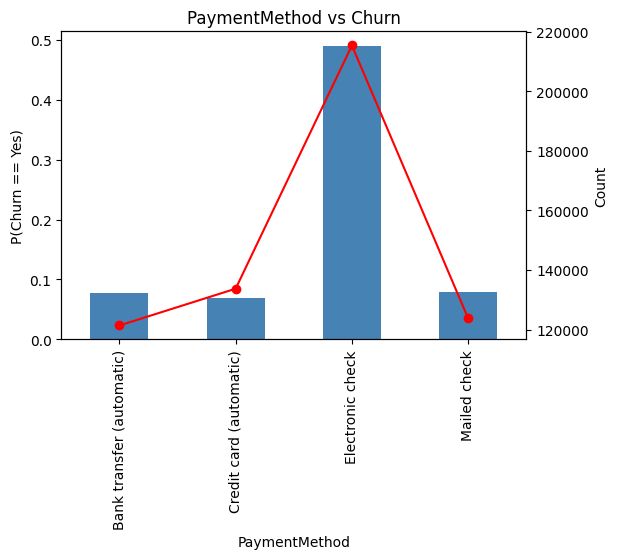

In [29]:
def plot_cat_target(df, feature):
    prob = df.groupby(feature)["target"].mean()
    count = df.groupby(feature)["target"].count()
    
    fig, ax1 = plt.subplots(figsize=(6,4))
    
    prob.plot(kind="bar", ax=ax1, color="steelblue")
    ax1.set_ylabel("P(Churn == Yes)")
    ax1.set_title(f"{feature} vs Churn")
    
    ax2 = ax1.twinx()
    count.plot(kind="line", ax=ax2, color="red", marker="o")
    ax2.set_ylabel("Count")
    
    plt.show()

for i in cat_cols:
    if i == 'Churn':
        continue
    plot_cat_target(df, i)


C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\1734409087.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby(pd.cut(temp["rank"], 20))["target"].mean()


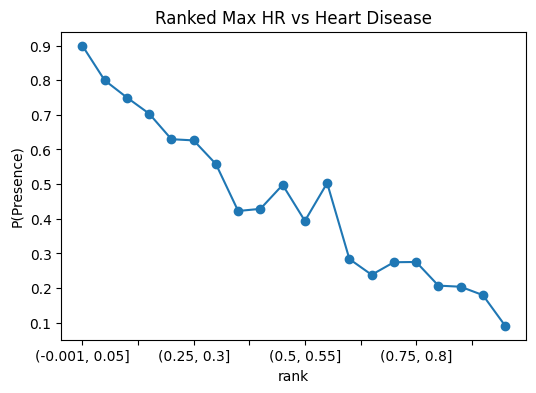

C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\1734409087.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby(pd.cut(temp["rank"], 20))["target"].mean()


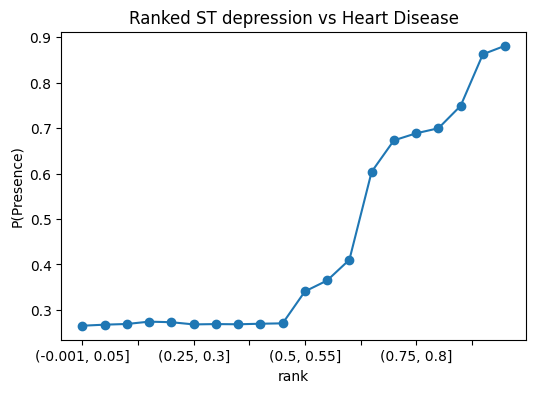

C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\1734409087.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby(pd.cut(temp["rank"], 20))["target"].mean()


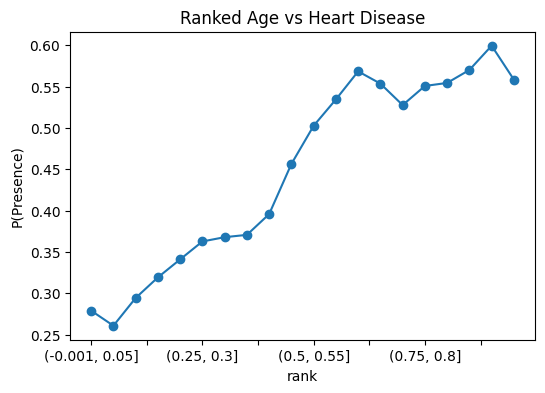

C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\1734409087.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby(pd.cut(temp["rank"], 20))["target"].mean()


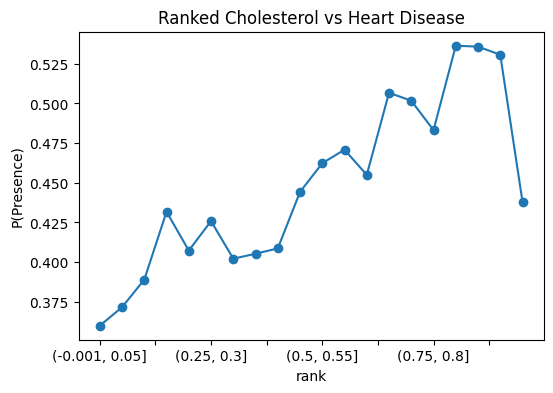

In [86]:
def rank_plot(df, feature):
    temp = df[[feature, "target"]].sort_values(feature)
    temp["rank"] = np.linspace(0, 1, len(temp))
    
    grouped = temp.groupby(pd.cut(temp["rank"], 20))["target"].mean()
    
    plt.figure(figsize=(6,4))
    grouped.plot(marker="o")
    plt.title(f"Ranked {feature} vs Heart Disease")
    plt.ylabel("P(Presence)")
    plt.show()
rank_plot(df, "Max HR")
rank_plot(df, "ST depression")
rank_plot(df, "Age")
rank_plot(df, "Cholesterol")


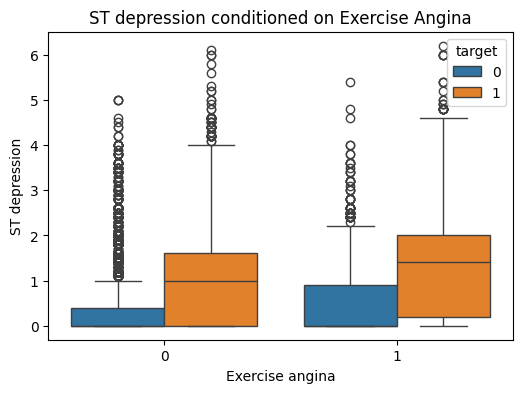

In [87]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Exercise angina",
    y="ST depression",
    hue="target",
    data=df.sample(50000, random_state=42)
)
plt.title("ST depression conditioned on Exercise Angina")
plt.show()


C:\Users\16yas\AppData\Local\Temp\ipykernel_40292\3616420372.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = temp.pivot_table(


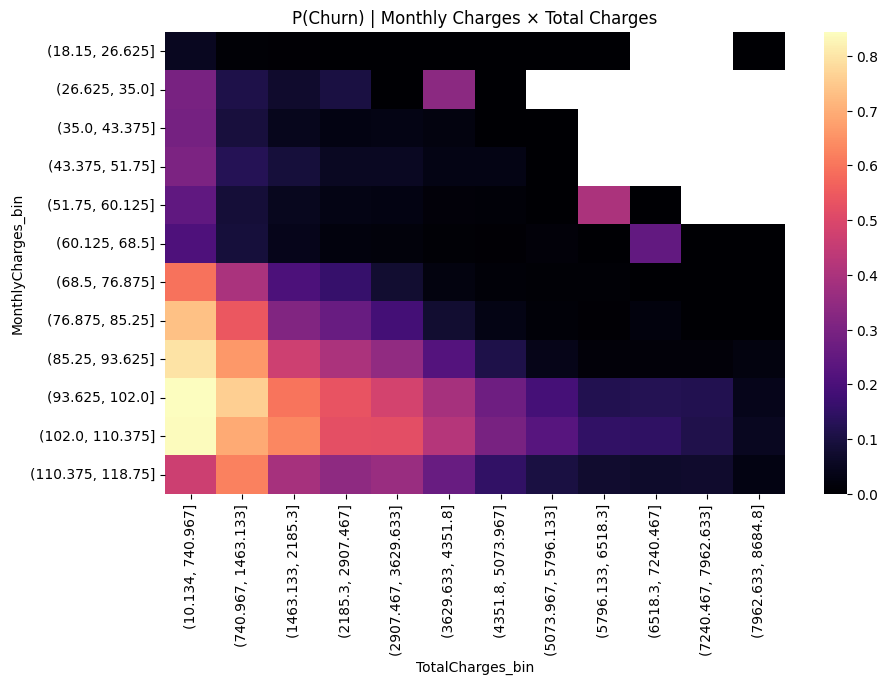

In [32]:
temp = df.copy()
temp["MonthlyCharges_bin"] = pd.cut(temp["MonthlyCharges"], 12)
temp["TotalCharges_bin"] = pd.cut(temp["TotalCharges"], 12)

pivot = temp.pivot_table(
    values="target",
    index="MonthlyCharges_bin",
    columns="TotalCharges_bin",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="magma")
plt.title("P(Churn) | Monthly Charges × Total Charges")
plt.show()


In [33]:
target_corr = df.drop(columns=["target"])\
                .corrwith(df["target"])\
                .sort_values()

plt.figure(figsize=(6,6))
target_corr.plot(kind="barh")
plt.title("Correlation with Target")
plt.show()


ValueError: could not convert string to float: 'Male'

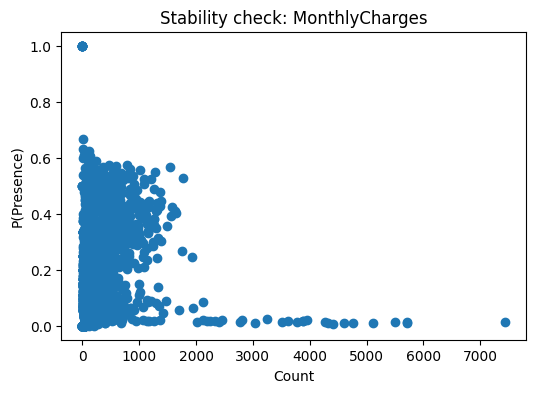

KeyError: 'ToatalCharges'

In [34]:
def cat_stability(df, feature):
    temp = df.groupby(feature)["target"].agg(["mean", "count"])
    plt.figure(figsize=(6,4))
    plt.scatter(temp["count"], temp["mean"])
    plt.xlabel("Count")
    plt.ylabel("P(Presence)")
    plt.title(f"Stability check: {feature}")
    plt.show()
cat_stability(df, "MonthlyCharges")
cat_stability(df, "ToatalCharges")


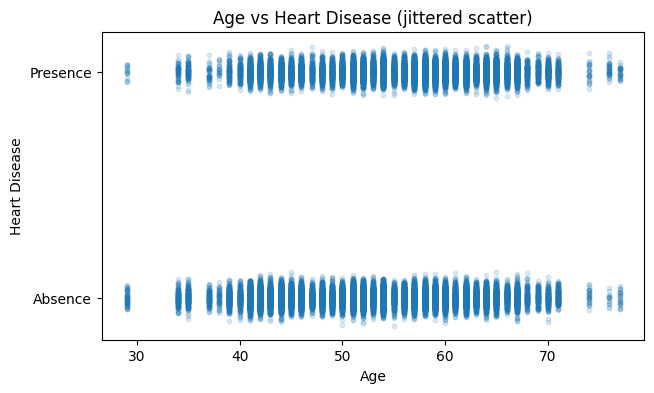

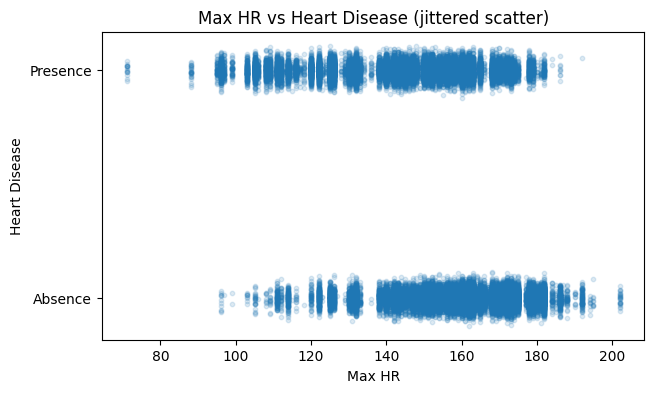

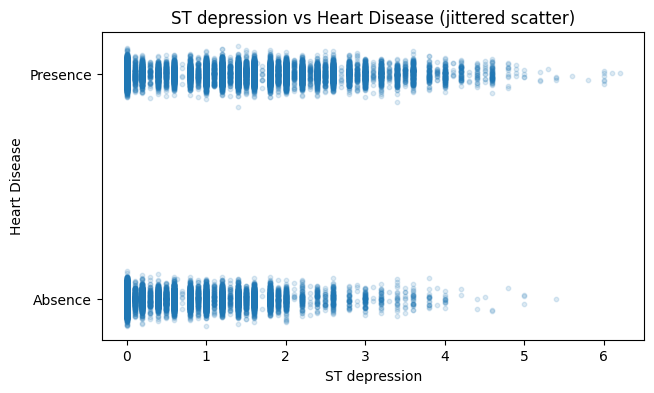

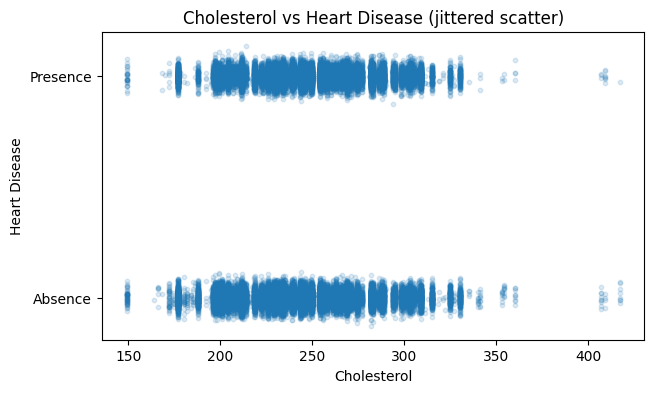

In [92]:
def target_scatter(df, feature, sample_size=50000):
    sample = df.sample(sample_size, random_state=42)

    y_jitter = sample["target"] + np.random.normal(0, 0.03, size=len(sample))

    plt.figure(figsize=(7,4))
    plt.scatter(
        sample[feature],
        y_jitter,
        alpha=0.15,
        s=10
    )
    plt.yticks([0, 1], ["Absence", "Presence"])
    plt.xlabel(feature)
    plt.ylabel("Heart Disease")
    plt.title(f"{feature} vs Heart Disease (jittered scatter)")
    plt.show()
target_scatter(df, "Age")
target_scatter(df, "Max HR")
target_scatter(df, "ST depression")
target_scatter(df, "Cholesterol")


C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\2627747390.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby("bin")[feature].mean()
C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\2627747390.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob = temp.groupby("bin")["target"].mean()


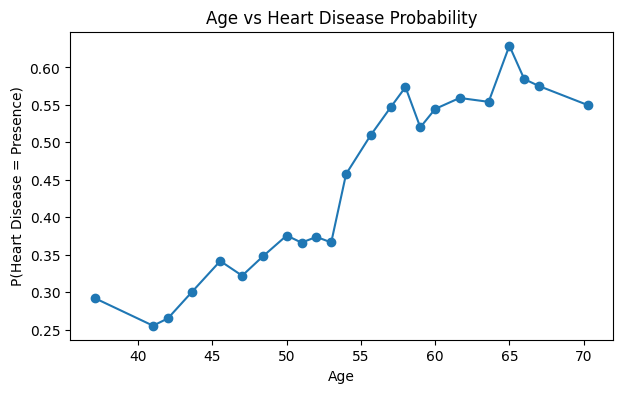

C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\2627747390.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby("bin")[feature].mean()
C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\2627747390.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob = temp.groupby("bin")["target"].mean()


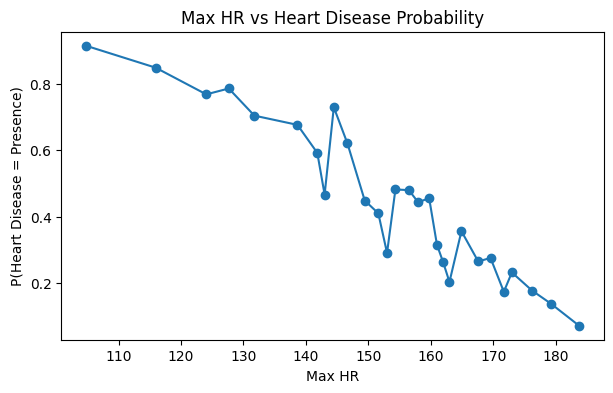

C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\2627747390.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby("bin")[feature].mean()
C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\2627747390.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob = temp.groupby("bin")["target"].mean()


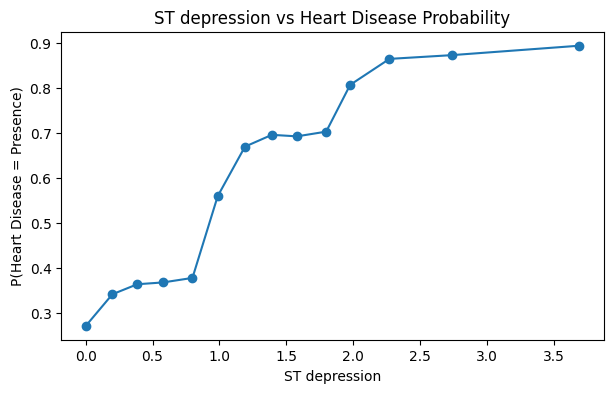

In [93]:
def target_prob_scatter(df, feature, bins=30):
    temp = df[[feature, "target"]].copy()
    temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")

    grouped = temp.groupby("bin")[feature].mean()
    prob = temp.groupby("bin")["target"].mean()

    plt.figure(figsize=(7,4))
    plt.scatter(grouped, prob)
    plt.plot(grouped, prob)
    plt.xlabel(feature)
    plt.ylabel("P(Heart Disease = Presence)")
    plt.title(f"{feature} vs Heart Disease Probability")
    plt.show()
target_prob_scatter(df, "Age")
target_prob_scatter(df, "Max HR")
target_prob_scatter(df, "ST depression")


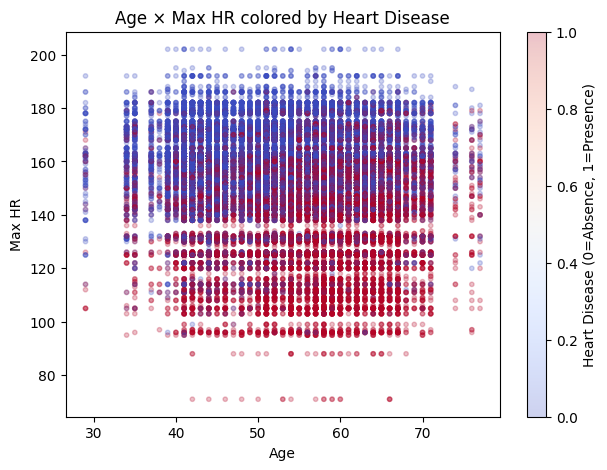

In [94]:
sample = df.sample(60000, random_state=42)

plt.figure(figsize=(7,5))
plt.scatter(
    sample["Age"],
    sample["Max HR"],
    c=sample["target"],
    cmap="coolwarm",
    alpha=0.25,
    s=10
)
plt.colorbar(label="Heart Disease (0=Absence, 1=Presence)")
plt.xlabel("Age")
plt.ylabel("Max HR")
plt.title("Age × Max HR colored by Heart Disease")
plt.show()


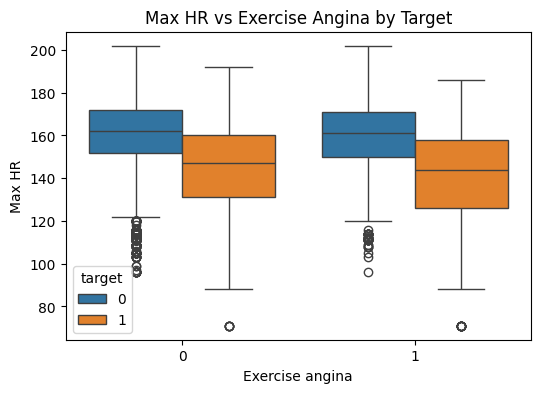

In [70]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Exercise angina",
    y="Max HR",
    hue="target",
    data=df.sample(50000, random_state=42)
)
plt.title("Max HR vs Exercise Angina by Target")
plt.show()


C:\Users\16yas\AppData\Local\Temp\ipykernel_29200\3027649495.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = temp.pivot_table(


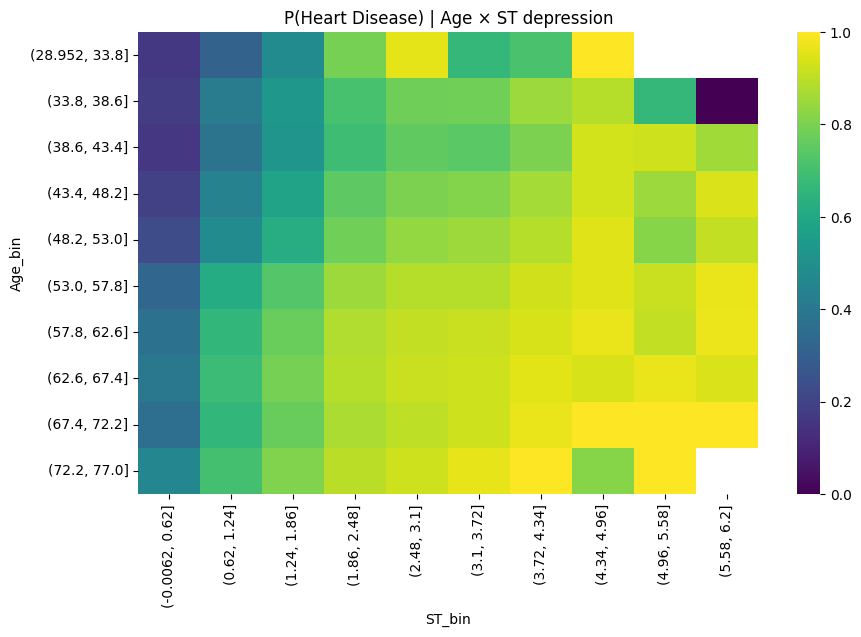

In [71]:
temp = df.copy()
temp["Age_bin"] = pd.cut(temp["Age"], bins=10)
temp["ST_bin"] = pd.cut(temp["ST depression"], bins=10)

pivot = temp.pivot_table(
    values="target",
    index="Age_bin",
    columns="ST_bin",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("P(Heart Disease) | Age × ST depression")
plt.show()


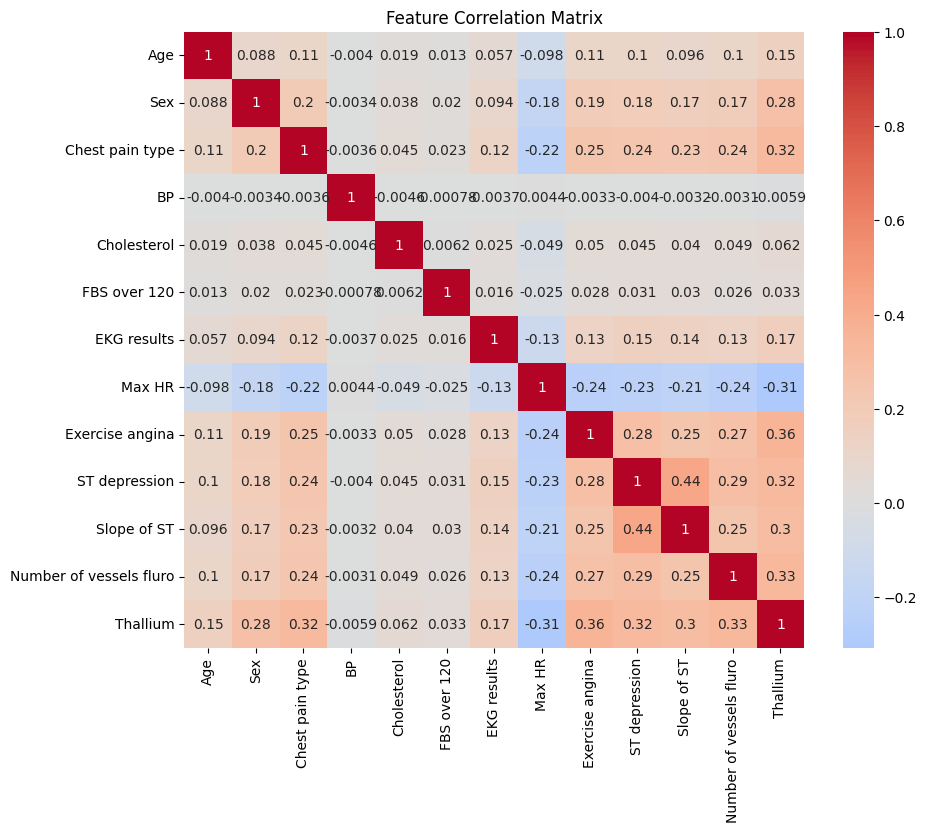

In [78]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.drop(columns=["target"])
      .corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    
)
plt.title("Feature Correlation Matrix")
plt.show()


In [162]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import numpy as np

# ----------------------------
# Feature / target
# ----------------------------
X = df.drop(columns=["target"])
y = df["target"]

num_cols = [
    'Thallium', 'Sex', 'Slope of ST', 'Age',
    'Number of vessels fluro', 'Exercise angina',
    'Max HR', 'Chest pain type', 'EKG results',
    'Cholesterol', 'FBS over 120', 'BP',
    'ST depression'
]

X['Thallium_x2'] = X['Thallium'] / X['Slope of ST']
newly_adds = ['Thallium_x2']
# num_cols.extend(newly_adds)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

coefs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Scaling (fit ONLY on train)
    # ----------------------------
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])

    # ----------------------------
    # Model
    # ----------------------------
    log_reg = LogisticRegression(
        max_iter=10000,
        solver="lbfgs"
    )

    log_reg.fit(X_train_scaled[num_cols], y_train)

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = log_reg.predict(X_val_scaled[num_cols])
    y_proba = log_reg.predict_proba(X_val_scaled[num_cols])[:, 1]

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    coefs.append(log_reg.coef_[0])

    print(f"Fold {fold} done")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average coefficients
# ----------------------------
coef_mean = pd.Series(
    np.mean(coefs, axis=0),
    index=num_cols
).sort_values(ascending=False)

print("\nAverage coefficients across folds:")
print(coef_mean)

print("\nAverage odds ratios:")
print(np.exp(coef_mean))


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

CV Results (mean ± std):
ACCURACY  : 0.8831 ± 0.0007
ROC_AUC   : 0.9505 ± 0.0003
PRECISION : 0.8798 ± 0.0006
RECALL    : 0.8563 ± 0.0017
F1        : 0.8679 ± 0.0009

Average coefficients across folds:
Thallium                   0.963492
Chest pain type            0.888216
Number of vessels fluro    0.705441
Exercise angina            0.541903
Sex                        0.483501
ST depression              0.462346
Slope of ST                0.444247
Age                        0.351990
EKG results                0.218882
Cholesterol                0.096726
BP                         0.004105
FBS over 120              -0.010938
Max HR                    -0.837782
dtype: float64

Average odds ratios:
Thallium                   2.620832
Chest pain type            2.430790
Number of vessels fluro    2.024739
Exercise angina            1.719275
Sex                        1.621743
ST depression              1.587795
Slope of ST      

Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64

## XGBOSST

Index(['Thallium', 'Sex', 'Slope of ST', 'Age', 'Number of vessels fluro',
       'Exercise angina', 'Max HR', 'Chest pain type', 'EKG results',
       'Cholesterol', 'FBS over 120', 'BP', 'ST depression', 'Thallium_x_age'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.90      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

Fold 1 done with ROC-AUC: 0.9554601575681437
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     69509
           1       0.88      0.87      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

Fold 2 done with ROC-AUC: 0.9544971147836496
         

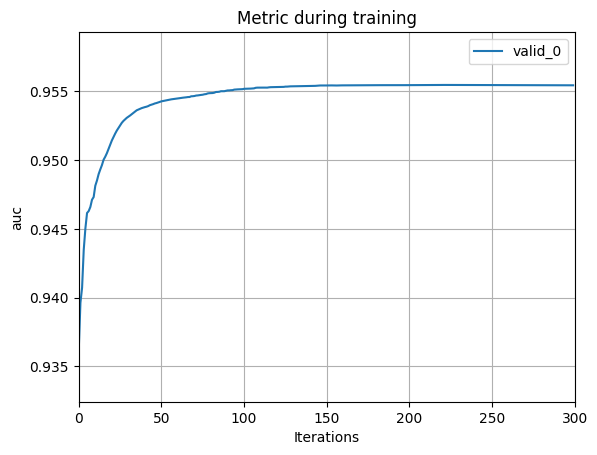

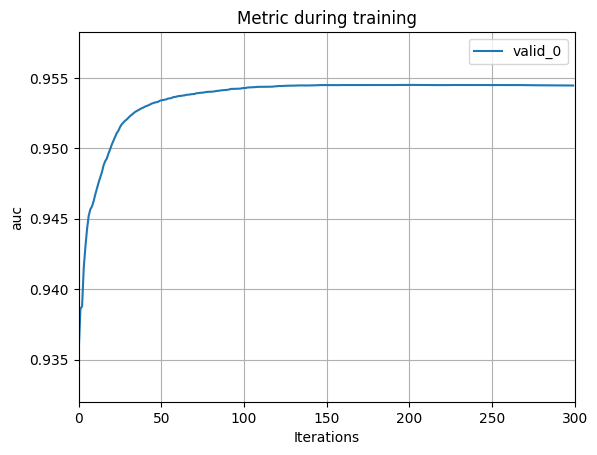

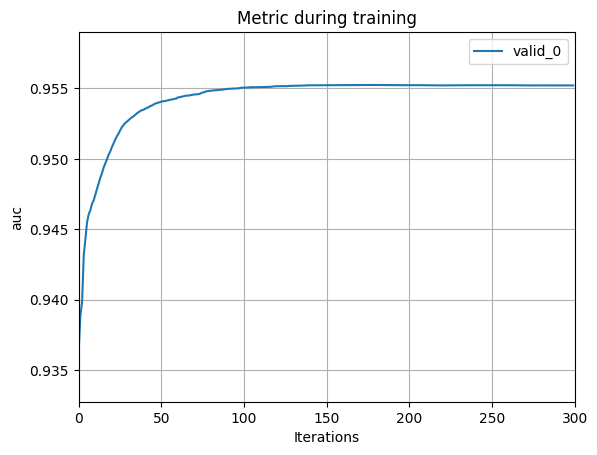

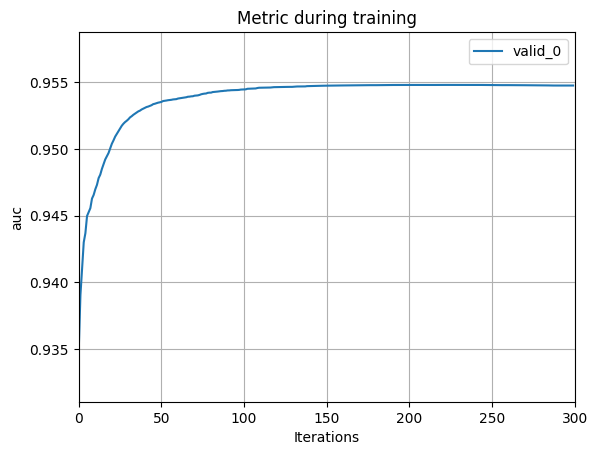

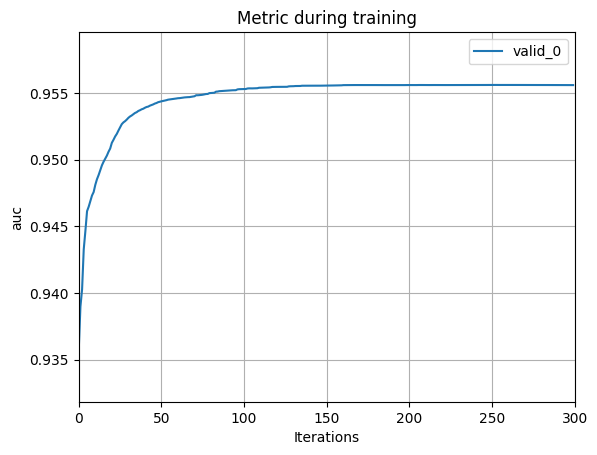

In [184]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

# ----------------------------
# Feature / target
# ----------------------------
X = df.drop(columns=["target"])
y = df["target"]

X_test = test.drop(columns='id')

num_cols = [
    'Thallium', 'Sex', 'Slope of ST', 'Age',
    'Number of vessels fluro', 'Exercise angina',
    'Max HR', 'Chest pain type', 'EKG results',
    'Cholesterol', 'FBS over 120', 'BP',
    'ST depression'
]
cat_cols = [
    # 'Sex',
    'Chest pain type',
    # 'Exercise angina',
    # 'Number of vessels fluro',
    # 'Thallium'
]
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    '''Preprocess of features.'''
    # df['Number of vessels fluro'] = (df['Number of vessels fluro'] - 3) * -1
    new_cols = []
    # bins = [0, 35, 55, 70, 80]
    # labels = [1, 2, 3, 4]
    # df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

    # X['Thallium_x2'] = X['Thallium'] / X['Slope of ST']
    # X_test['Thallium_x2'] = X_test['Thallium'] / X_test['Slope of ST']
    
    # bins = [0, 1, 2, 3, 4.5, 5.5]
    # labels = [1, 2, 3, 4, 5]
    # df['dep x age'] = pd.cut(df['ST depression'], bins=bins, labels=labels, right=False).astype('float')
    # df['dep x age'] = df['Age'] / df['dep x age']
    # new_cols.append('dep x age')
    # df[cat_cols] = df[cat_cols].astype('category')
    # data = pd.get_dummies(df[cat_cols], drop_first=True)
    # print(data.columns)
    # df = pd.concat([df.drop(columns=cat_cols), data], axis=1)
    # print(df.columns)
    # new_cols = ['Age Group']
    df['Thallium_x_age'] = df['Thallium'] * (df['Age']**0.5)
    # df["num_fluro"] = (df['Number of vessels fluro'] > 0).astype(int)
    # df['st_slope'] = (df['Slope of ST'] > 1).astype(int)
    # df = df.drop(columns= [ 'Slope of ST'])
    # df["st_x_age"] = (df['Age'] * np.log1p(df['ST depression']))
    # new_cols.append('st_x_age')
    # for i in new_cols:
    #     if i not in num_cols:
    #         num_cols.append(i)
    # num_cols.append('Thallium_x2')
    return df


X = preprocess(X[num_cols].copy())
X_test = preprocess(X_test[num_cols].copy())

print(X.columns)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

importances = []

X_res = np.zeros(len(X_test))
X_res_oof = np.zeros(len(X))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Model
    # ----------------------------
    xgb = LGBMClassifier(
        objective="binary",
        metric="auc",

        n_estimators=300,
        learning_rate=0.1,

        max_depth=-1,          # let num_leaves control complexity
        num_leaves=48,

        subsample=0.9,
        colsample_bytree=0.9,

        min_child_samples=100,
        reg_alpha=5,
        reg_lambda=5,

        random_state=42,
        n_jobs=-1,
        verbose=-1,
        early_stopping_rounds = 150
    )


    xgb.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        # verbose=False
    )

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = xgb.predict(X_val, num_iteration=xgb.best_iteration_)
    y_proba = xgb.predict_proba(X_val, num_iteration=xgb.best_iteration_)[:, 1]
    X_res += xgb.predict_proba(X_test, num_iteration=xgb.best_iteration_)[:, 1]/5
    X_res_oof += xgb.predict_proba(X, num_iteration=xgb.best_iteration_)[:, 1]/5

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    importances.append(xgb.feature_importances_)
    lgb.plot_metric(booster=xgb)
    print(classification_report(y_val, y_pred))
    print(f"Fold {fold} done", f"with ROC-AUC: {metrics['roc_auc'][-1]}")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average feature importance
# ----------------------------
importance_mean = pd.Series(
    np.mean(importances, axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nAverage feature importances:")
print(importance_mean)

sub_df = pd.DataFrame({'id': test['id'], 'Heart Disease': X_res})


In [53]:
xgb.best_iteration_

229

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

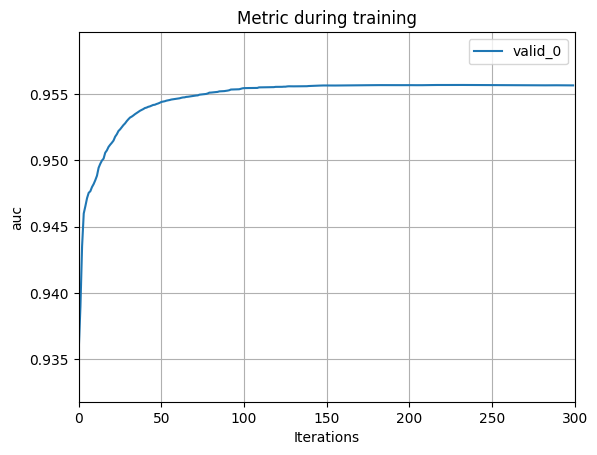

In [52]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

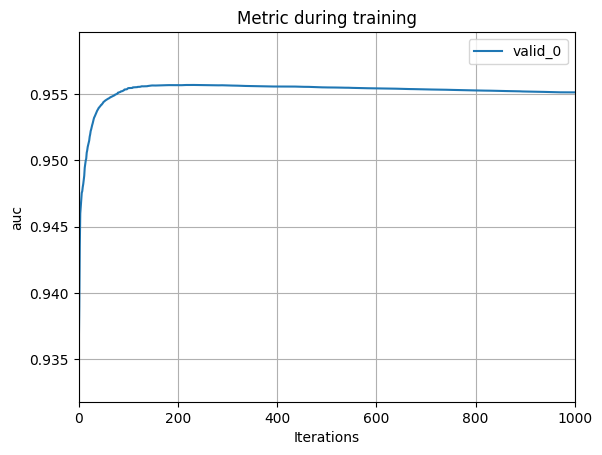

In [50]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

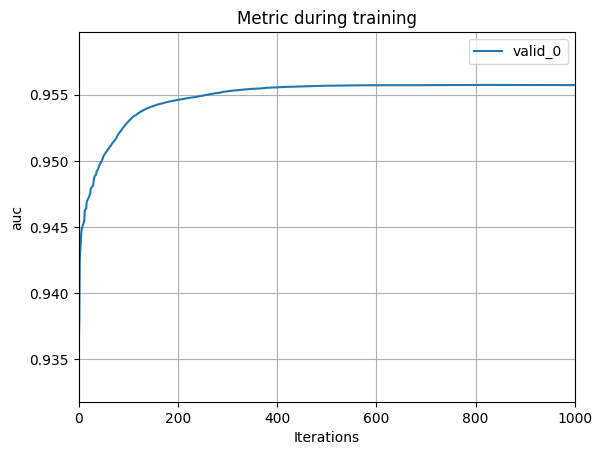

In [48]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

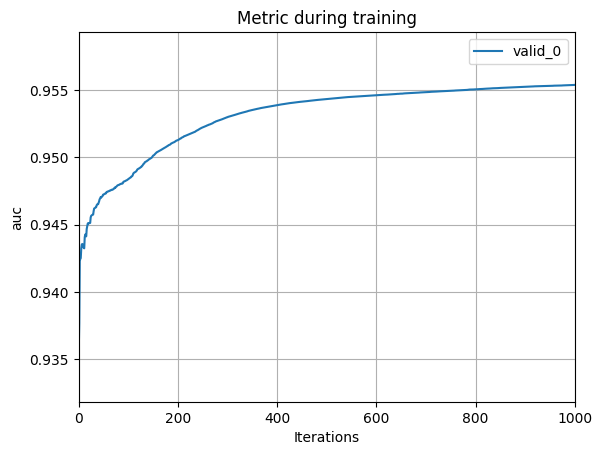

In [46]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

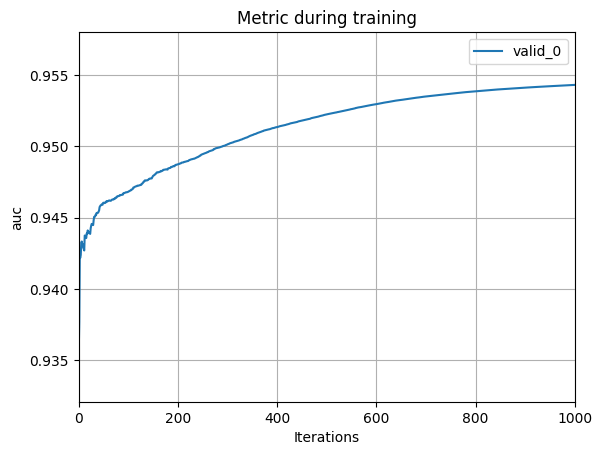

In [44]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

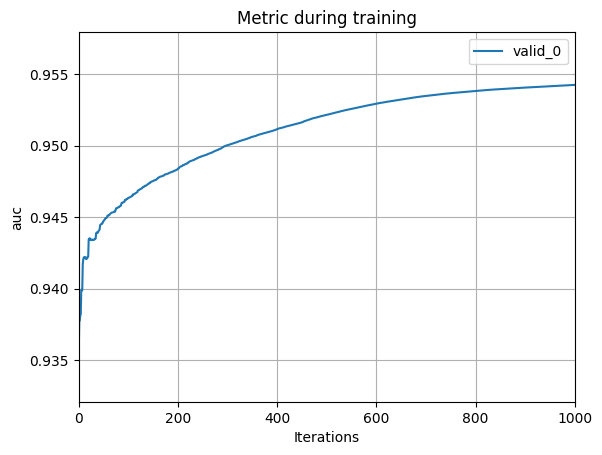

In [42]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

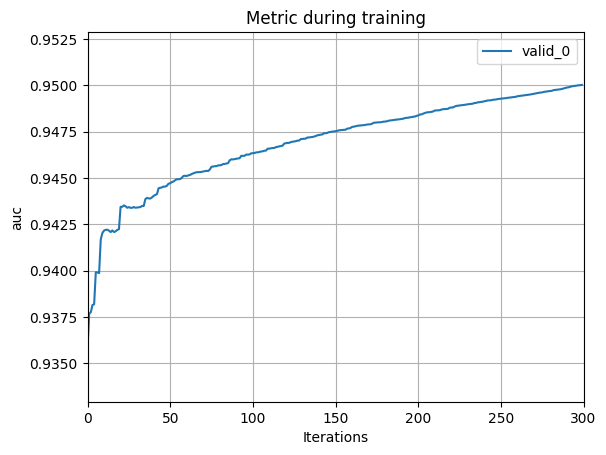

In [40]:
lgb.plot_metric(booster=xgb)

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

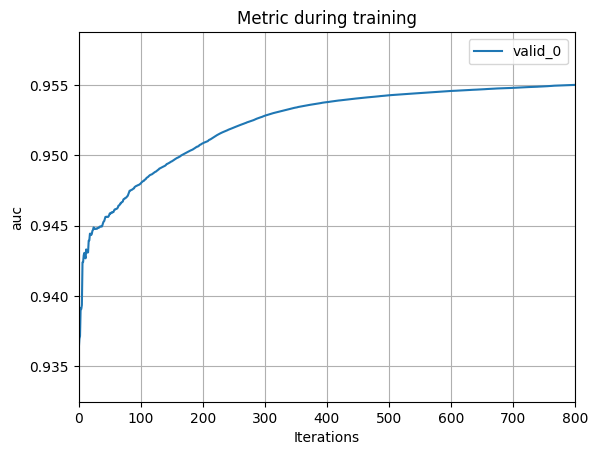

In [30]:
lgb.plot_metric(booster=xgb)

In [32]:
booster = xgb.booster_
tree_info = booster.dump_model()["tree_info"]

# tree from iteration 0
print(tree_info[0])


{'tree_index': 0, 'num_leaves': 48, 'num_cat': 0, 'shrinkage': 1, 'tree_structure': {'split_index': 0, 'split_feature': 13, 'split_gain': 177168, 'threshold': 1.0000000180025095e-35, 'decision_type': '<=', 'default_left': True, 'missing_type': 'None', 'internal_value': -0.207375, 'internal_weight': 124655, 'internal_count': 504000, 'left_child': {'split_index': 1, 'split_feature': 6, 'split_gain': 39021, 'threshold': 3.5000000000000004, 'decision_type': '<=', 'default_left': True, 'missing_type': 'None', 'internal_value': -0.216946, 'internal_weight': 75797.9, 'internal_count': 306463, 'left_child': {'split_index': 9, 'split_feature': 3, 'split_gain': 2552.780029296875, 'threshold': 1.0000000180025095e-35, 'decision_type': '<=', 'default_left': True, 'missing_type': 'None', 'internal_value': -0.222569, 'internal_weight': 46956.4, 'internal_count': 189852, 'left_child': {'split_index': 18, 'split_feature': 5, 'split_gain': 1079.010009765625, 'threshold': 146.50000000000003, 'decision_ty

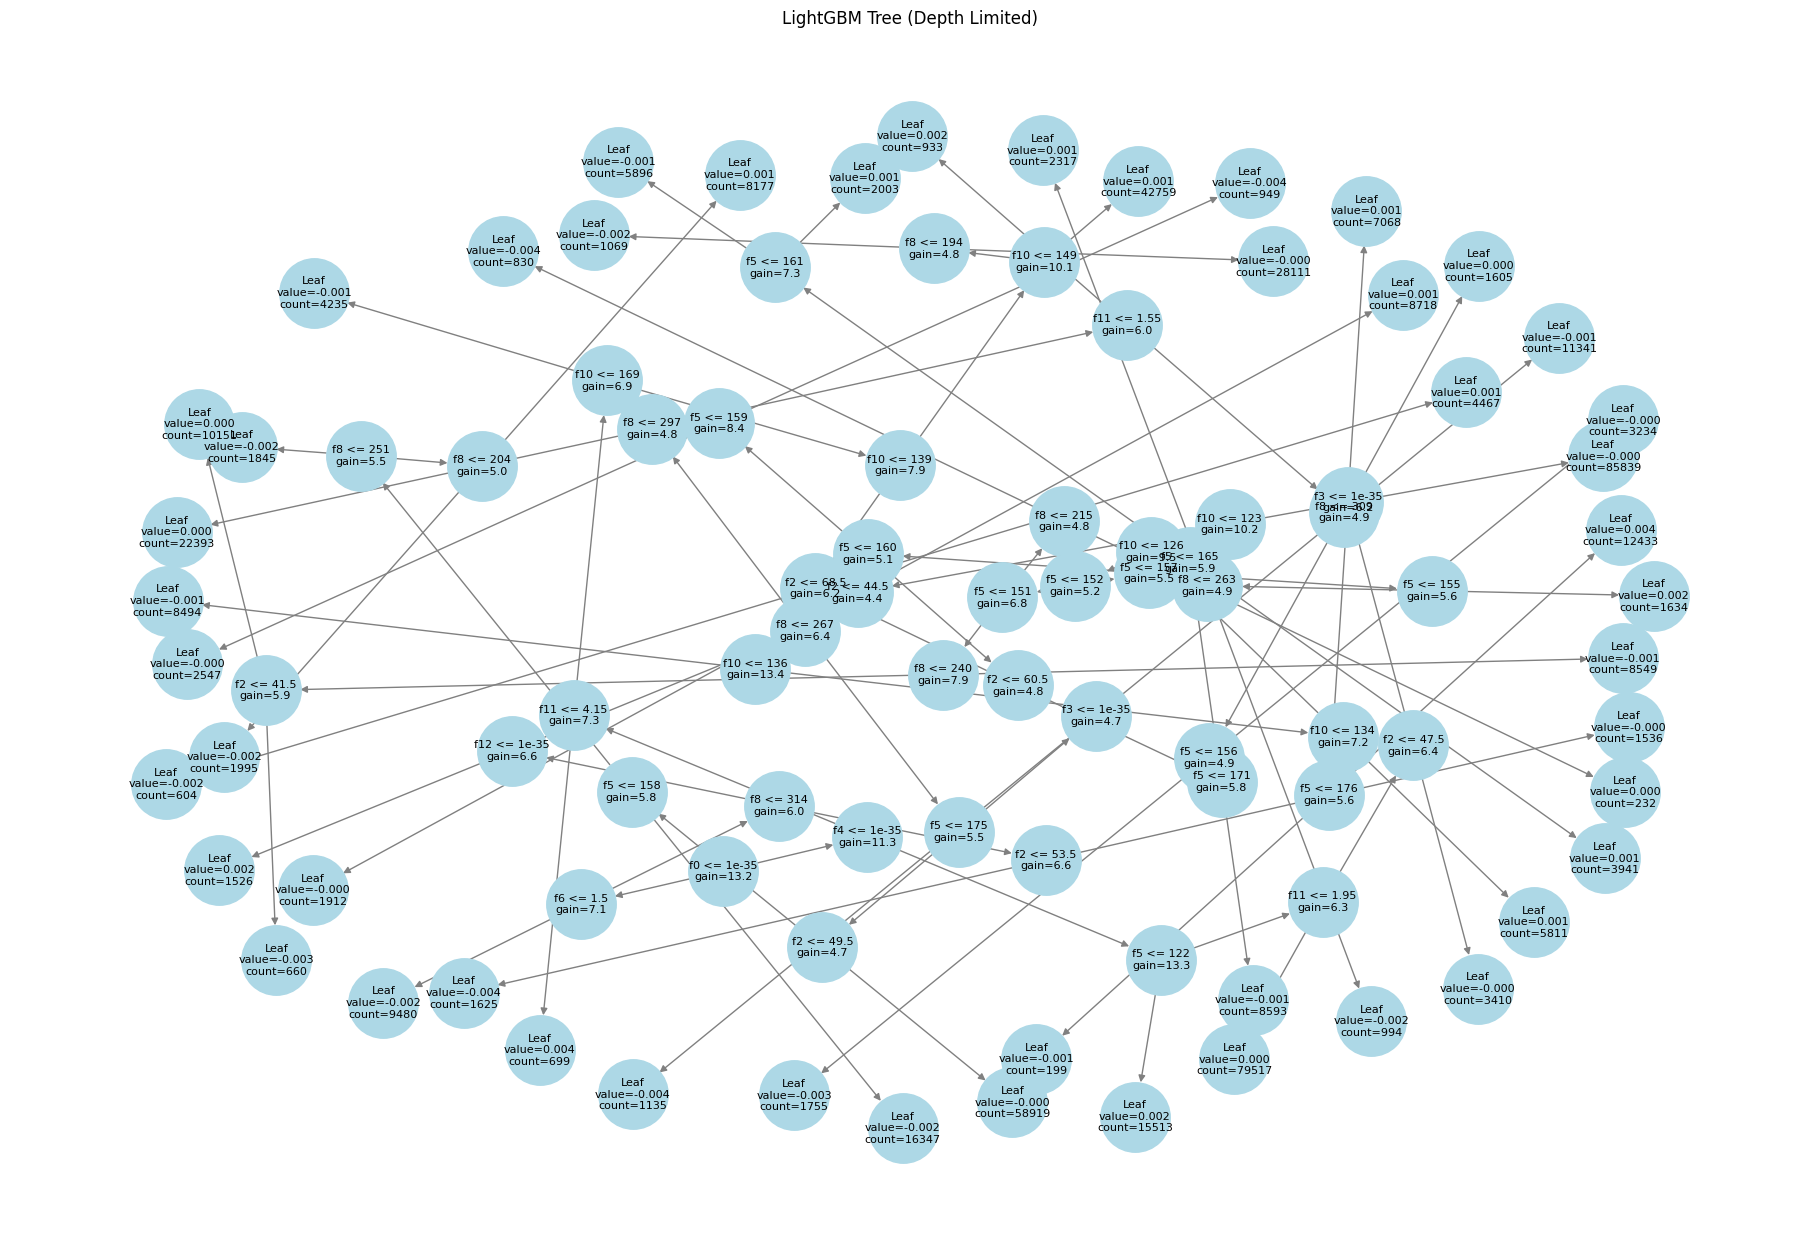

In [38]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_lgb_tree(tree, max_depth=3):
    G = nx.DiGraph()
    labels = {}

    def walk(node, parent=None, depth=0):
        if depth > max_depth:
            return

        node_id = id(node)

        if "leaf_index" in node:
            label = f"Leaf\nvalue={node['leaf_value']:.3f}\ncount={node['leaf_count']}"
        else:
            label = (
                f"f{node['split_feature']} <= {node['threshold']:.3g}\n"
                f"gain={node['split_gain']:.1f}"
            )

        labels[node_id] = label
        G.add_node(node_id)

        if parent is not None:
            G.add_edge(parent, node_id)

        if "left_child" in node:
            walk(node["left_child"], node_id, depth + 1)
        if "right_child" in node:
            walk(node["right_child"], node_id, depth + 1)

    walk(tree["tree_structure"])

    pos = nx.nx_pydot.graphviz_layout(G, prog="dot") if False else nx.spring_layout(G, seed=42)

    plt.figure(figsize=(18, 12))
    nx.draw(
        G, pos,
        labels=labels,
        node_size=2500,
        node_color="lightblue",
        font_size=8,
        edge_color="gray"
    )
    plt.title("LightGBM Tree (Depth Limited)")
    plt.show()

plot_lgb_tree( booster.dump_model()["tree_info"][799], max_depth=20)

In [ ]:
#               precision    recall  f1-score   support

#            0       0.90      0.90      0.90     69509
#            1       0.88      0.87      0.88     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 1 done with ROC-AUC: 0.955548222586477
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69509
#            1       0.88      0.87      0.87     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 2 done with ROC-AUC: 0.9545607642271182
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69509
#            1       0.88      0.87      0.88     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 3 done with ROC-AUC: 0.9553328255739608
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69509
#            1       0.88      0.87      0.87     56491

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 4 done with ROC-AUC: 0.9548917821824026
#               precision    recall  f1-score   support

#            0       0.89      0.91      0.90     69510
#            1       0.88      0.87      0.88     56490

#     accuracy                           0.89    126000
#    macro avg       0.89      0.89      0.89    126000
# weighted avg       0.89      0.89      0.89    126000

# Fold 5 done with ROC-AUC: 0.9557331318215955

# CV Results (mean ± std):
# ACCURACY  : 0.8885 ± 0.0009
# ROC_AUC   : 0.9552 ± 0.0004
# PRECISION : 0.8818 ± 0.0006
# RECALL    : 0.8676 ± 0.0020
# F1        : 0.8746 ± 0.0012

# Average feature importances:
# Max HR                     9480.0
# Cholesterol                6978.0
# Age                        5475.4
# BP                         3936.0
# ST depression              3456.4
# Number of vessels fluro    1808.0
# Chest pain type            1704.4
# Sex                        1115.0
# Exercise angina            1029.4
# Slope of ST                 884.0
# Thallium                    859.4
# EKG results                 669.0
# FBS over 120                205.0
# dtype: float64

Number of under-predicted positives: 36631
Total number of positives: 282454
Fraction of positives under-predicted: 0.1297
Sample of under-predicted positive cases:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,target
70,64,0,3,120,211,0,0,162,0,0.0,1,0,7,1
72,54,1,3,112,226,0,0,156,0,1.2,2,1,3,1
82,52,1,4,125,263,0,2,174,0,1.6,3,0,3,1
94,51,1,3,118,254,0,2,154,0,0.6,1,0,7,1
106,64,0,4,110,274,0,2,170,0,0.6,1,0,6,1


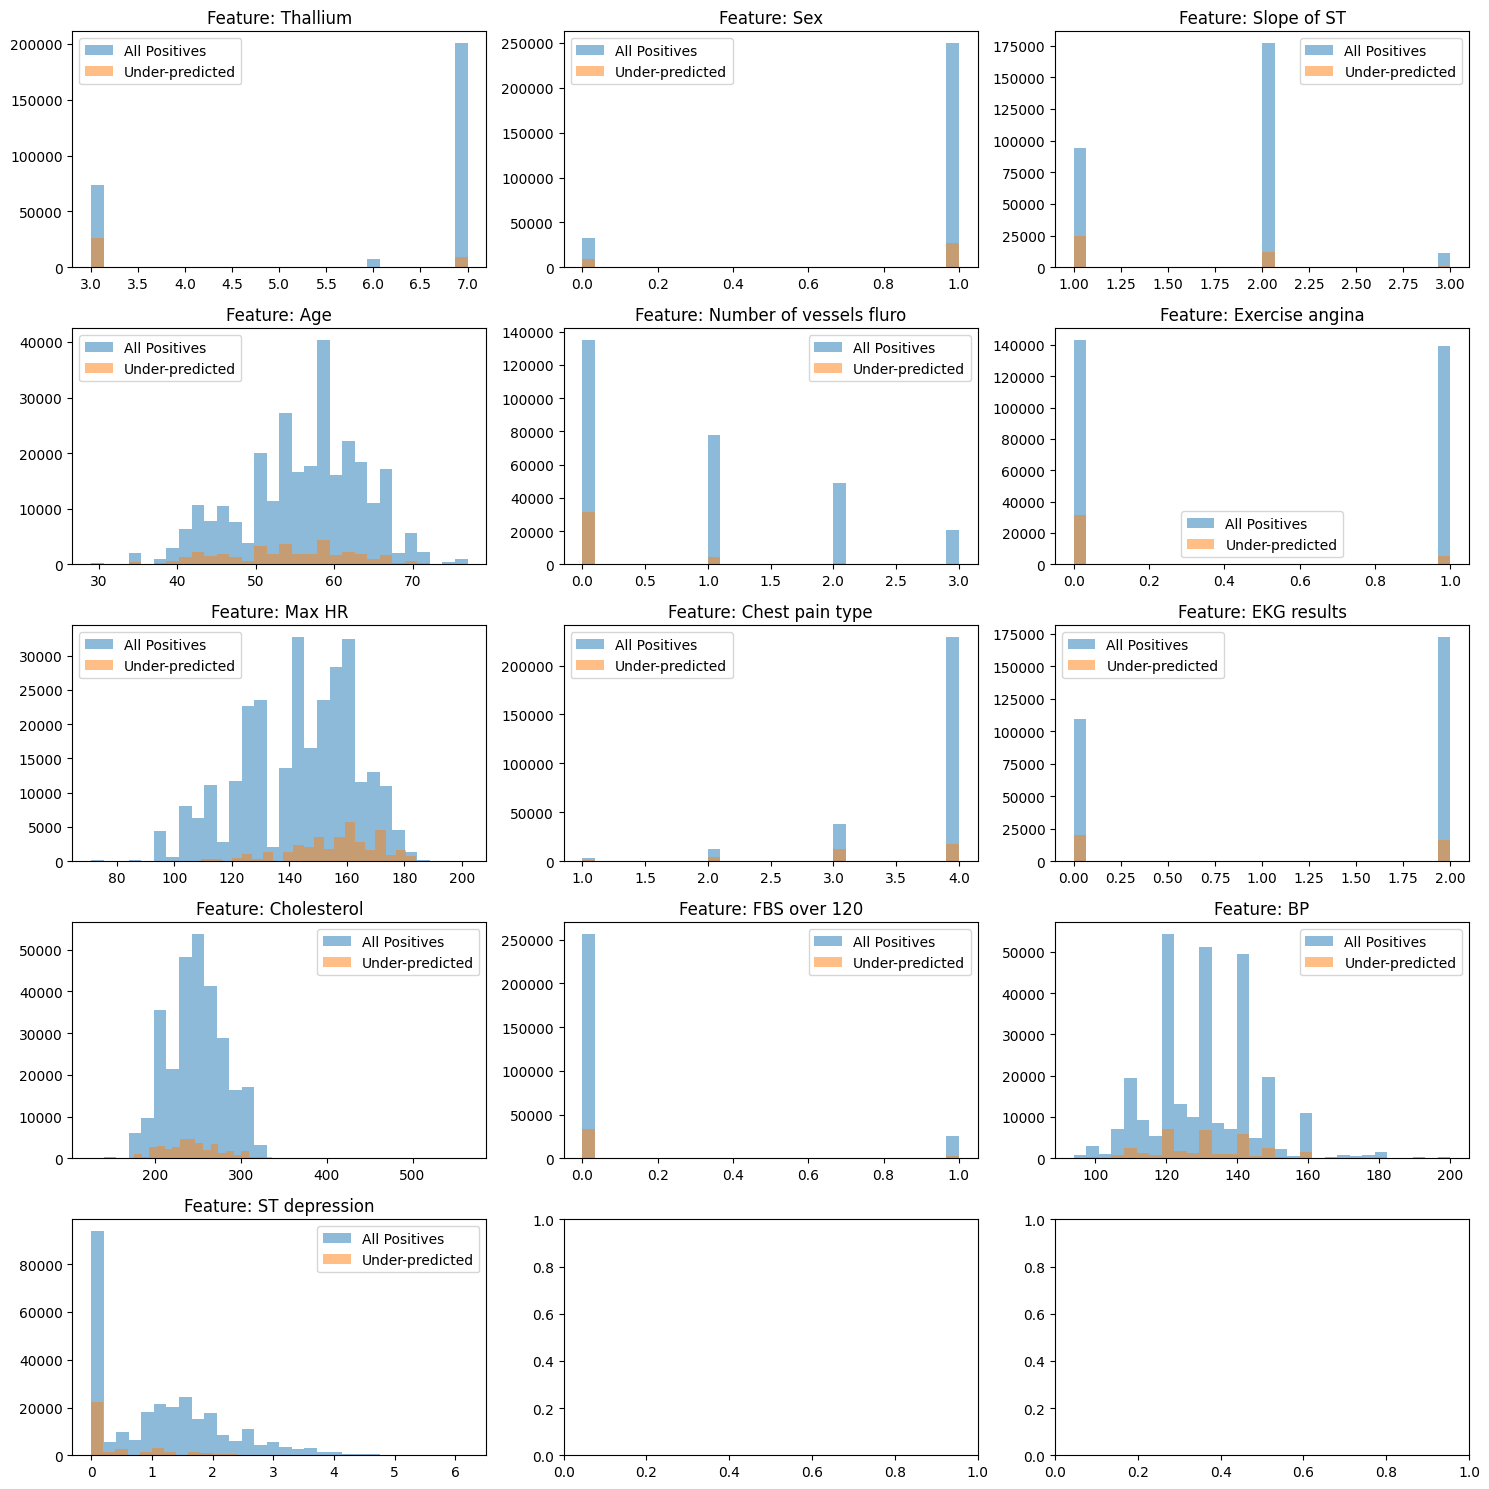

In [206]:
# Analyze under-predictions in X_res_oof (predicted probability < 0.2, but true target == 1)
threshold = 0.5
under_pred_idx = (X_res_oof < threshold) & (y.values == 1)
under_pred_count = under_pred_idx.sum()
total_true_positives = (y.values == 1).sum()

print(f"Number of under-predicted positives: {under_pred_count}")
print(f"Total number of positives: {total_true_positives}")
print(f"Fraction of positives under-predicted: {under_pred_count / total_true_positives:.4f}")

# Show some examples
under_pred_examples = df.loc[under_pred_idx]
print("Sample of under-predicted positive cases:")
display(under_pred_examples.head())

# Compare feature distributions for under-predicted vs. all positives
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(num_cols)//3 + 1, 3, figsize=(15, 15))
for idx, col in enumerate(num_cols):
    axes[idx//3, idx%3].hist(df.loc[(y.values == 1), col], bins=30, alpha=0.5, label='All Positives')
    axes[idx//3, idx%3].hist(under_pred_examples[col], bins=30, alpha=0.5, label='Under-predicted')
    axes[idx//3, idx%3].set_title(f"Feature: {col}")
    axes[idx//3, idx%3].legend()
plt.tight_layout()
plt.show()

In [ ]:
import itertools

# Visualize feature x feature interactions for under-predicted positives vs all positives


features = num_cols  # already defined as list of feature names

# Select a subset of feature pairs for visualization (e.g., top 5 important features)
top_features = importance_mean.head(5).index.tolist()
feature_pairs = list(itertools.combinations(top_features, 2))

import matplotlib.pyplot as plt

for f1, f2 in feature_pairs:
    plt.figure(figsize=(8, 6))
    plt.scatter(
        df.loc[(y.values == 1), f1],
        df.loc[(y.values == 1), f2],
        alpha=0.1, label='All Positives', s=5, color='C0'
    )
    plt.scatter(
        under_pred_examples[f1],
        under_pred_examples[f2],
        alpha=0.3, label='Under-predicted', s=5, color='C1'
    )
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f'Feature Interaction: {f1} vs {f2}')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [184]:
sub_df.to_parquet(r'submission04.parquet', index = False)

In [ ]:
# sub 00 

# CV Results (mean ± std):
# ACCURACY  : 0.8884 ± 0.0008
# ROC_AUC   : 0.9551 ± 0.0004
# PRECISION : 0.8816 ± 0.0004
# RECALL    : 0.8675 ± 0.0020
# F1        : 0.8745 ± 0.0010

# LB        : 0.95323

In [197]:
under_pred_examples['target'].value_counts()

target
1    36631
Name: count, dtype: int64

In [212]:
under_pred_examples.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'target'],
      dtype='object')

In [225]:
train[['ST depression','Heart Disease']].value_counts()

ST depression  Heart Disease
0.00           Absence          230116
               Presence          84823
1.60           Presence          19911
1.20           Presence          19569
1.40           Presence          18936
                                 ...  
0.06           Presence              1
2.12           Presence              1
1.64           Absence               1
5.40           Absence               1
5.90           Presence              1
Name: count, Length: 122, dtype: int64

In [227]:
train['ST depression'].describe()

count    630000.000000
mean          0.716028
std           0.948472
min           0.000000
25%           0.000000
50%           0.100000
75%           1.400000
max           6.200000
Name: ST depression, dtype: float64

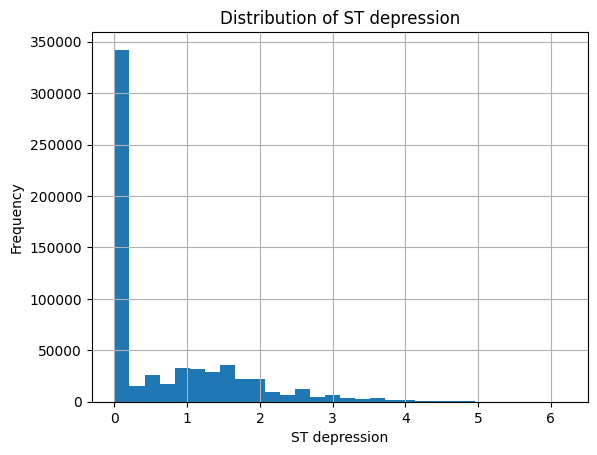

In [101]:
TARGET = 'Heart Disease'
CAT_COLS   = [
    'Sex', 
    'Chest pain type', 
    'FBS over 120', 
    'EKG results', 
    'Exercise angina', 
    'Slope of ST', 
    'Number of vessels fluro', 
    'Thallium'
] 
NUM_COLS   = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

for i in CAT_COLS:
    print('---------------')
    print(train[i].value_counts())

---------------
Sex
1    450283
0    179717
Name: count, dtype: int64
---------------
Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64
---------------
FBS over 120
0    579608
1     50392
Name: count, dtype: int64
---------------
EKG results
0    320116
2    308562
1      1322
Name: count, dtype: int64
---------------
Exercise angina
0    457553
1    172447
Name: count, dtype: int64
---------------
Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64
---------------
Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64
---------------
Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64


In [106]:
eda.columns
eda[TARGET] = eda[TARGET].map({'Absence': 0, 'Presence': 1})

In [107]:
(eda['Age'] * eda['ST depression']).corr(eda['Heart Disease'])

np.float64(0.43911034644848)

In [108]:
(eda['Age']).corr(eda['Heart Disease'])

np.float64(0.21209131286269142)

In [109]:
(eda['ST depression']).corr(eda['Heart Disease'])

np.float64(0.4306405912515558)

In [183]:
print((eda['Age']**2 * np.log1p(eda['ST depression'])).corr(eda['Heart Disease']))
print((eda['Age'] * np.log1p(eda['ST depression'])).corr(eda['Heart Disease']))
print((np.log1p(eda['Age']) * np.log1p(eda['ST depression'])).corr(eda['Heart Disease']))
print((np.sqrt(eda['Age']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print((np.sqrt(eda['Age']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print(((eda['Age']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print(((eda['Thallium']) * (eda['ST depression'])).corr(eda['Heart Disease']))
print(((eda['Age'])**0.5 * (eda['ST depression'])).corr(eda['Heart Disease']))

print("xx")
print(((eda['Thallium'])**0.5 * (eda['ST depression'])).corr(eda['Heart Disease']))

print((np.log1p(eda['Thallium'])).corr(eda['Heart Disease']))
print(((eda['Thallium'])).corr(eda['Heart Disease']))
print(((eda['Thallium']) * np.log1p(eda['ST depression'])).corr(eda['Heart Disease'])) # -- 0.5198690733942132
print(((eda['Thallium']) * (eda['Age'])**0.5).corr(eda['Heart Disease'])) 
print(((eda['Thallium'])**0.5 * (eda['Age'])).corr(eda['Heart Disease'])) 
print(((eda['Thallium']) * np.log1p(eda['ST depression']) * np.log1p(eda['Age'])).corr(eda['Heart Disease']))


0.44771815900261663
0.4514027723211994
0.4445067587750504
0.4368046867131314
0.4368046867131314
0.43911034644848
0.4908167846318111
0.4368046867131314
xx
0.4740376440068133
0.6058069893103024
0.6057763854486644
0.5198690733942132
0.6154148773491708
0.5729868218857301
0.5218104819958872
